# 🏥 Healthcare Veri Seti — Data Science Bitirme Projesi

**Veri Seti:** [Kaggle — Healthcare Dataset (prasad22)](https://www.kaggle.com/datasets/prasad22/healthcare-dataset)  
**Hedef:** Hasta test sonucunu tahmin etmek (Normal / Abnormal / Inconclusive)  
**İkincil Hedef:** Fatura tutarını tahmin etmek (Regression)

---

## Proje Akışı
1. Kütüphane ve Veri Yükleme  
2. Keşifsel Veri Analizi (EDA)  
3. Veri Ön İşleme  
4. Classification — Test Sonucu Tahmini  
5. Regression — Fatura Tahmini  
6. Model Karşılaştırması ve Sonuç

## 1. Kütüphane ve Veri Yükleme

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
import joblib

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Tüm kütüphaneler başarıyla yüklendi.')

Tüm kütüphaneler başarıyla yüklendi.


In [4]:
# Kaggle'dan indirip aynı klasöre koyun: healthcare_dataset.csv
df = pd.read_csv('../data/healthcare_dataset.csv')

print(f'Satır sayısı : {df.shape[0]:,}')
print(f'Sütun sayısı : {df.shape[1]}')
print(f'\nSütunlar:')
print(df.columns.tolist())
df.head()

Satır sayısı : 55,500
Sütun sayısı : 15

Sütunlar:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
print('=== Veri Tipleri & Eksik Değer Kontrolü ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_sayisi': df.isnull().sum(),
    'null_yuzde': (df.isnull().sum() / len(df) * 100).round(2)
})
print(info)

print('\n=== Temel İstatistikler ===')
df.describe()

=== Veri Tipleri & Eksik Değer Kontrolü ===
                      dtype  null_sayisi  null_yuzde
Name                 object            0         0.0
Age                   int64            0         0.0
Gender               object            0         0.0
Blood Type           object            0         0.0
Medical Condition    object            0         0.0
Date of Admission    object            0         0.0
Doctor               object            0         0.0
Hospital             object            0         0.0
Insurance Provider   object            0         0.0
Billing Amount      float64            0         0.0
Room Number           int64            0         0.0
Admission Type       object            0         0.0
Discharge Date       object            0         0.0
Medication           object            0         0.0
Test Results         object            0         0.0

=== Temel İstatistikler ===


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


# 2. Keşifsel Veri Analizi (EDA)
## 2.1 Sayısal Değişkenler


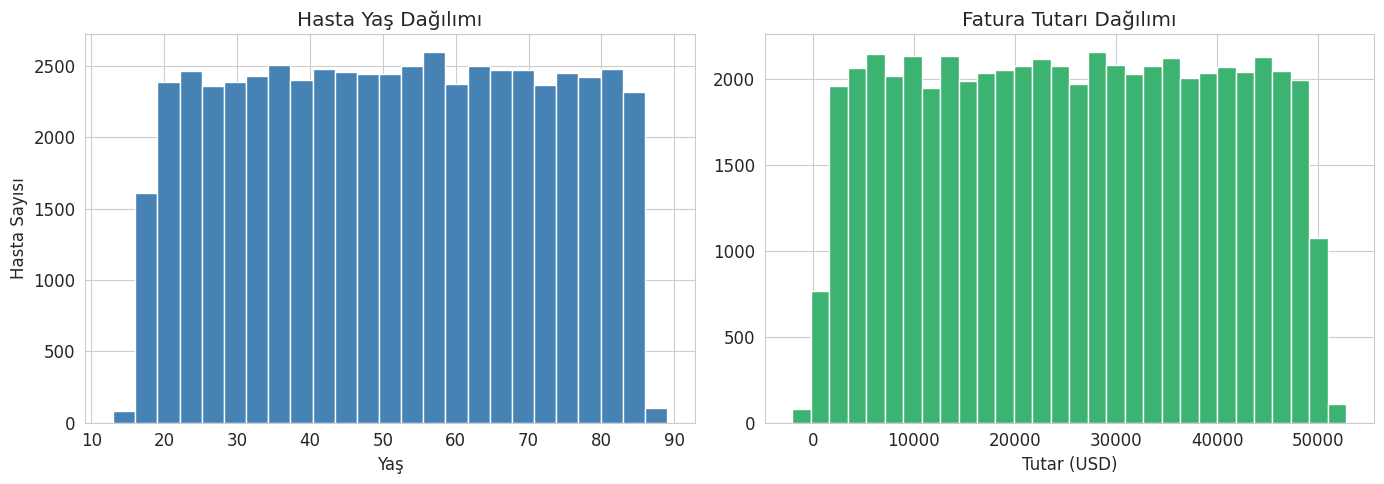

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Hasta Yaş Dağılımı')
axes[0].set_xlabel('Yaş')
axes[0].set_ylabel('Hasta Sayısı')

axes[1].hist(df['Billing Amount'], bins=30, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Fatura Tutarı Dağılımı')
axes[1].set_xlabel('Tutar (USD)')

plt.tight_layout()
plt.savefig('eda_sayisal.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Kategorik Değişkenler

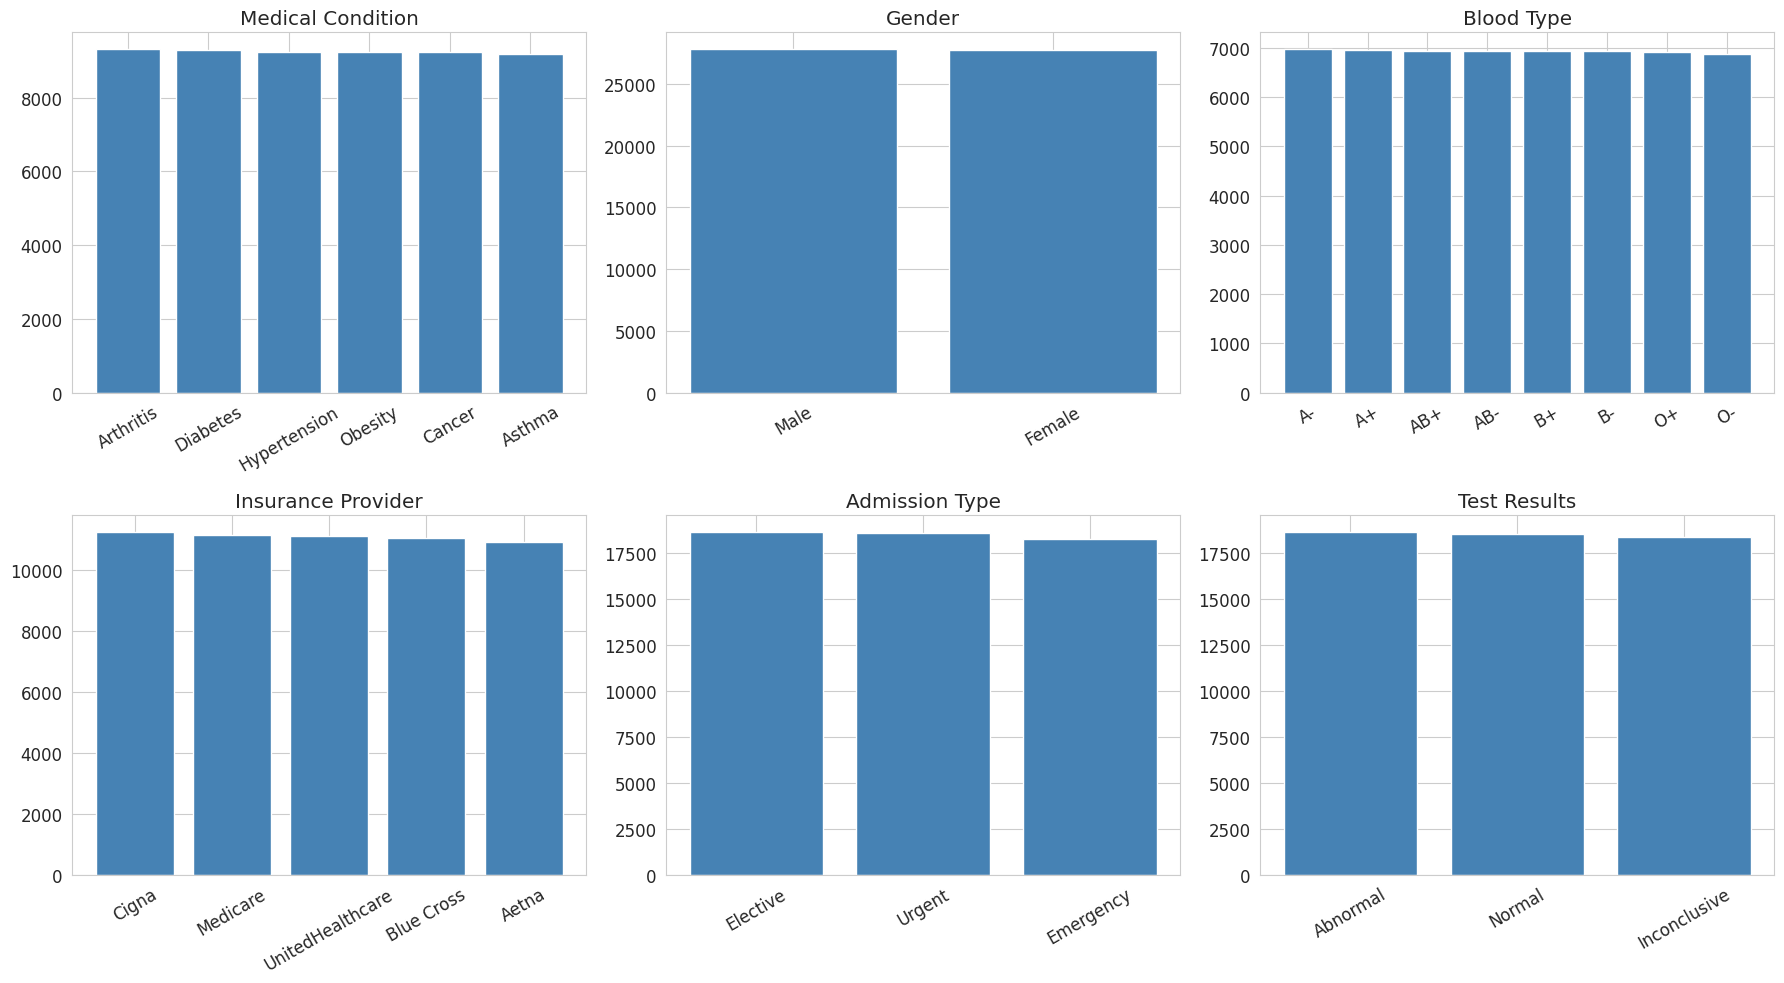

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cat_cols = ['Medical Condition', 'Gender', 'Blood Type',
            'Insurance Provider', 'Admission Type', 'Test Results']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_kategorik.png', dpi=150, bbox_inches='tight')
plt.show()